# 1. Title, Student, Group and Member 3 Scope
**IT3091 — House Price Prediction: Preprocessing & Feature Engineering**  
**Ahamed M.A.W · IT24103352 · Group 2026-AI-08K**

This notebook converts upstream findings into justified, reproducible property features. It covers semantic missingness, encoding, imputation, feature engineering, feature review and preprocessing verification. It does not train a regression estimator, evaluate predictions or select a model. SalePrice remains in original dollars.

Reusable code lives in `src/member_03/preprocessing.py`. The CSV decision log and feature schema are companion evidence. This notebook is not the final written Member 3 report.

# 2. Member 1 / Member 2 Handover Summary
| Upstream evidence | Member 3 implication |
|---|---|
| Member 1: supervised regression, property unit, pre-listing price estimate | Separate target/IDs and define prediction-time availability. |
| Member 2: right-skewed target and unusual large houses | Preserve target; investigate rather than delete unusual rows. |
| Member 2: semantic garage/basement missingness | Distinguish absent amenities from unknown descriptors. |
| Member 2: area, quality, location and dominant variables | Preserve meaningful types; review without target-driven selection. |

Sources: [initial submission](../../reports/Member_01/IT3091_Group_Assignment_2026-AI-08K_Initial_Submission.md), [Member 2 notebook](../Member_02/Member2_DataUnderstanding_EDA_DQ.ipynb), [Member 2 report](../../reports/Member_02/Member2_Data_Understanding_EDA_Data_Quality_Report.md), [assignment descriptor](../../docs/ML-%5BGroup-Assignment-Descriptor%5D.md), [balanced plan](../../docs/ML-%5BGroup-8-Balanced-Project-Plan%5D.md), [CourseWeb notices](../../docs/ML-%5BASSIGMENT-NOTICES-COURSEWEB%5D.md), and [supplied dictionary](../../data/raw/house-prices-advanced-regression-techniques/data_description.txt).

Member 2 handed over findings, not cleaned data or a fitted preprocessor. These checks extend the evidence only where preprocessing needs it.

# 3. Reproducibility and Repository Paths
Run from the repository root or a directory beneath it. No machine-specific path is embedded. Existing project dependencies suffice for preprocessing. The deterministic temporary split later is solely for correctness verification.

In [1]:
from pathlib import Path
import sys, hashlib, platform, copy, warnings
sys.dont_write_bytecode = True
import numpy as np
import pandas as pd
import sklearn
import scipy
import json
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from scipy import sparse
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from IPython.display import display

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data/raw/house-prices-advanced-regression-techniques/train.csv').is_file()), None)
assert ROOT is not None, 'Run from inside the repository.'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.member_03 import preprocessing as prep
from src.member_03 import load_ames_data, build_preprocessor, get_feature_names
RANDOM_STATE = 42
RAW_DIR = ROOT / 'data/raw/house-prices-advanced-regression-techniques'
REPORT_DIR = ROOT / 'reports/Member_03'
versions = {'Python': platform.python_version(), 'pandas': pd.__version__, 'numpy': np.__version__,
            'scikit-learn': sklearn.__version__, 'scipy': scipy.__version__, 'matplotlib': matplotlib.__version__}
display(pd.Series(versions, name='Executed environment').to_frame())
fingerprints = {p.name: hashlib.sha256(p.read_bytes()).hexdigest()
                for p in sorted(RAW_DIR.iterdir()) if p.is_file()}
display(pd.Series(fingerprints, name='SHA256').to_frame())

,Executed environment
Python,3.14.3
pandas,2.3.3
numpy,2.4.2
scikit-learn,1.8.0
scipy,1.17.1
matplotlib,3.10.8


,SHA256
data_description.txt,2194c5e1f1f22aa570d1dfe8e59e74c4e3db4885bf51c7...
sample_submission.csv,c21ed9898f8c2111d42c542c75ee0d68b892f0a0528696...
test.csv,3559f4ee4f04729814c85f9f597331e02bdb81b7c96c1a...
train.csv,ed142e0a97bd49fc3b46c930209c55750fc4e806f5430c...


# 4. Load Raw Ames Housing Data
`keep_default_na=False, na_values=['']` preserves literal NA and None; only genuinely blank cells become missing. Retain these frames unchanged for audit. The cleaner interprets numerical NA tokens and structural categories separately.

In [2]:
train_raw, test_raw = load_ames_data(ROOT)
train_snapshot, test_snapshot = train_raw.copy(deep=True), test_raw.copy(deep=True)
assert train_raw.shape == (1460, 81) and test_raw.shape == (1459, 80)
assert 'SalePrice' in train_raw and 'SalePrice' not in test_raw
assert train_raw.Id.is_unique and test_raw.Id.is_unique
sample = pd.read_csv(RAW_DIR / 'sample_submission.csv')
assert sample.Id.equals(test_raw.Id)
display(pd.DataFrame({'file': ['train.csv', 'test.csv', 'sample_submission.csv'],
                      'rows': [len(train_raw), len(test_raw), len(sample)],
                      'columns': [81, 80, 2],
                      'role': ['labelled properties', 'unlabelled properties', 'format example, NOT ground truth']}))

,file,rows,columns,role
0,train.csv,1460,81,labelled properties
1,test.csv,1459,80,unlabelled properties
2,sample_submission.csv,1459,2,"format example, NOT ground truth"


# 5. Schema and Prediction-Input Contract
The default assumes property information available before listing. SaleType, SaleCondition, YrSold, MoSold and MiscVal are excluded because their availability/provenance is unestablished. This is not a claim that they are unrelated to price. They cannot affect cleaning indirectly either. No sale-year-derived ages are implemented.

Keep target, IDs and audit fields separately. The cleaner enforces this allowlist even when a caller supplies the entire raw frame.

In [3]:
y = train_raw['SalePrice'].copy()
train_ids, test_ids = train_raw.Id.copy(), test_raw.Id.copy()
X = train_raw.loc[:, prep.PROPERTY_COLUMNS].copy()
X_kaggle = test_raw.loc[:, prep.PROPERTY_COLUMNS].copy()
assert X.columns.equals(X_kaggle.columns)
assert not set(prep.EXCLUDED) & set(X.columns)
assert len(X.columns) == len(set(prep.PROPERTY_COLUMNS)) == 74
display(pd.DataFrame({'excluded': prep.EXCLUDED,
                      'reason': ['alignment only', 'separate target', 'transaction context', 'transaction context',
                                 'actual sale timing', 'actual sale timing', 'unclear valuation provenance']}))

,excluded,reason
0,Id,alignment only
1,SalePrice,separate target
2,SaleType,transaction context
3,SaleCondition,transaction context
4,YrSold,actual sale timing
5,MoSold,actual sale timing
6,MiscVal,unclear valuation provenance


# 6. Focused Member 3 Data Audit
Inspect preprocessing-relevant evidence only. No repeated general correlation analysis or target plots are needed. Literal NA counts are not automatically counts of genuinely unknown values.

In [4]:
def numeric_evidence(frame, columns):
    return pd.DataFrame({c: pd.to_numeric(frame[c].mask(frame[c].eq('NA')), errors='raise')
                         for c in columns}, index=frame.index)

missing_tokens = pd.DataFrame({
    'train_NA_tokens': train_raw.eq('NA').sum(), 'test_NA_tokens': test_raw.eq('NA').sum(),
    'train_blank': train_raw.isna().sum(), 'test_blank': test_raw.isna().sum(),
}).fillna(0).astype(int)
display(missing_tokens.loc[missing_tokens.sum(axis=1).gt(0)])
default_masonry = pd.read_csv(RAW_DIR / 'train.csv', usecols=['MasVnrType']).MasVnrType.isna().sum()
display(pd.DataFrame({'interpretation': ['literal None (no veneer)', 'literal NA (unknown)', 'default-parser missing count'],
                      'training_count': [train_raw.MasVnrType.eq('None').sum(), train_raw.MasVnrType.eq('NA').sum(), default_masonry]}))
assert default_masonry == 872 and train_raw.MasVnrType.eq('NA').sum() == 8

,train_NA_tokens,test_NA_tokens,train_blank,test_blank
Alley,1369,1352,0,0
BsmtCond,37,45,0,0
BsmtExposure,38,44,0,0
BsmtFinSF1,0,1,0,0
BsmtFinSF2,0,1,0,0
BsmtFinType1,37,42,0,0
BsmtFinType2,38,42,0,0
BsmtFullBath,0,2,0,0
BsmtHalfBath,0,2,0,0
BsmtQual,37,44,0,0


,interpretation,training_count
0,literal None (no veneer),864
1,literal NA (unknown),8
2,default-parser missing count,872


This refines the preprocessing interpretation of Member 2's missingness evidence respectfully: 872 default-parser missing entries include 864 valid None categories and 8 unknown tokens. Preserve that distinction rather than treating all 872 as unknown.

The following compact table identifies exceptions without changing raw records.

In [5]:
audit_records = []
for label, raw in [('train', train_raw), ('test', test_raw)]:
    n = numeric_evidence(raw, prep.NUMERIC + ['YrSold', 'MiscVal'])
    rules = {
        'existing basement, descriptor NA': n.TotalBsmtSF.gt(0) & raw[prep.BSMT_CATS].eq('NA').any(axis=1),
        'existing garage, descriptor/year gap': (n.GarageArea.gt(0) | ~raw.GarageType.eq('NA')) & raw[prep.GARAGE_CATS + ['GarageYrBlt']].eq('NA').any(axis=1),
        'positive pool, quality NA': n.PoolArea.gt(0) & raw.PoolQC.eq('NA'),
        'None masonry with positive area': raw.MasVnrType.eq('None') & n.MasVnrArea.gt(0),
        'material recorded with zero area': ~raw.MasVnrType.isin(['NA', 'None']) & n.MasVnrArea.eq(0),
        'missing basement total': n.TotalBsmtSF.isna(),
        'year outside 1800..2100': pd.concat([n[c].notna() & ~n[c].between(1800, 2100) for c in prep.YEARS], axis=1).any(axis=1),
        'property year after sale': n[prep.YEARS].gt(n.YrSold, axis=0).any(axis=1),
        'remodel before build': n.YearRemodAdd.lt(n.YearBuilt),
        'misc type NA with positive value (audit only)': raw.MiscFeature.eq('NA') & n.MiscVal.gt(0),
    }
    for issue, mask in rules.items():
        audit_records.append({'file': label, 'issue': issue, 'count': int(mask.sum()),
                              'Ids': ', '.join(raw.loc[mask, 'Id'].astype(str))})
display(pd.DataFrame(audit_records))

,file,issue,count,Ids
0,train,"existing basement, descriptor NA",2,"333, 949"
1,train,"existing garage, descriptor/year gap",0,
2,train,"positive pool, quality NA",0,
3,train,None masonry with positive area,5,"625, 774, 1231, 1301, 1335"
4,train,material recorded with zero area,2,"689, 1242"
5,train,missing basement total,0,
6,train,year outside 1800..2100,0,
7,train,property year after sale,1,524
8,train,remodel before build,0,
9,train,misc type NA with positive value (audit only),0,


In [6]:
display(train_raw.loc[train_raw.Id.isin([524, 1299]),
                      ['Id', 'GrLivArea', 'SalePrice', 'OverallQual', 'SaleType', 'SaleCondition']])
dominance = pd.DataFrame({'feature': prep.DOMINANT_REVIEW,
    'training_dominant_share_pct': [round(train_raw[c].value_counts(dropna=False, normalize=True).iloc[0]*100, 2)
                                    for c in prep.DOMINANT_REVIEW]})
display(dominance)
raw_predictors = [c for c in test_raw.columns if c != 'Id']
# Normalise numeric dtypes on audit copies: preserved NA tokens can make test columns strings.
audit_train, audit_test = train_raw.copy(), test_raw.copy()
for frame in [audit_train, audit_test]:
    frame[prep.NUMERIC + ['YrSold', 'MoSold', 'MiscVal']] = numeric_evidence(frame, prep.NUMERIC + ['YrSold', 'MoSold', 'MiscVal'])
joined = pd.concat([audit_train.assign(source='train'), audit_test.assign(source='test')], ignore_index=True)
matches = joined.duplicated(subset=raw_predictors, keep=False)
display(joined.loc[matches, ['source', 'Id', 'Neighborhood', 'GrLivArea']])
assert train_raw[raw_predictors].duplicated().sum() == test_raw[raw_predictors].duplicated().sum() == 0
assert matches.sum() == 4
print('All observations retained. Cross-file matches are audit-only; no labels transferred.')

,Id,GrLivArea,SalePrice,OverallQual,SaleType,SaleCondition
523,524,4676,184750,10,New,Partial
1298,1299,5642,160000,10,New,Partial


,feature,training_dominant_share_pct
0,Street,99.59
1,Utilities,99.93
2,Condition2,98.97
3,RoofMatl,98.22
4,Heating,97.81
5,LowQualFinSF,98.22
6,KitchenAbvGr,95.34
7,3SsnPorch,98.36
8,PoolArea,99.52
9,PoolQC,99.52


,source,Id,Neighborhood,GrLivArea
193,train,194,Edwards,1709
829,train,830,Somerst,1223
2713,test,2714,Somerst,1223
2865,test,2866,Edwards,1709


All observations retained. Cross-file matches are audit-only; no labels transferred.


# 7. Missing-Value Decision Rules
| Situation | Treatment | Reason |
|---|---|---|
| Supported no garage/basement/fireplace/pool | Explicit absence; zero only for truly absent quantities | Absence is property information. |
| Existing amenity with unknown description | Unknown flag; applicable ordinal median or Unknown nominal category | Missing description does not imply absent amenity. |
| Entire basement block unknown (test 2121) | Unknown presence flag and applicable training medians | No measured area corroborates absence. |
| Basement quantity uniquely recoverable | Nonnegative arithmetic reconstruction | Uses observed information from that row. |
| LotFrontage unknown | Training median plus indicator | Dictionary gives no absence meaning. |
| Masonry type/area conflict | Retain area; unresolved material Unknown; flag | Do not invent material or erase measurement. |
| Literal NA in alley/fence/misc | Dictionary absence; actual blank Unknown | Preserves the original token meaning. |
| No-garage year | Neutral median placeholder with HasGarage=0 | Missing construction date is not year zero. |

Test 2550's miscellaneous-value contradiction is audit-only: excluded MiscVal cannot secretly repair MiscFeature. Sale-year contradictions likewise do not clean property predictors. The log preserves these limitations.

# 8. Semantic Feature Types
The schema covers every original column and derived feature before one-hot expansion. MSSubClass is nominal despite numeric storage. Quality/finish/exposure and other explicit dictionary orders are mapped deliberately. Shape/slope order is physical, not a price ordering. Basement finish types and Fence remain nominal: a single equally spaced quality ranking would introduce assumptions.

In [7]:
feature_schema = pd.read_csv(REPORT_DIR / 'feature_schema.csv', keep_default_na=False)
assert feature_schema.Feature.is_unique
assert set(train_raw.columns).issubset(set(feature_schema.Feature))
display(feature_schema.groupby(['Semantic_Type', 'Default_Use']).size().rename('feature_count').reset_index())
display(pd.DataFrame({'feature': list(prep.ORDINAL_ORDERS),
                      'documented_order': [' < '.join(v) for v in prep.ORDINAL_ORDERS.values()]}))

,Semantic_Type,Default_Use,feature_count
0,binary,include,58
1,count/capacity,include,9
2,identifier,exclude,1
3,nominal categorical,exclude,2
4,nominal categorical,include,24
5,numerical measurement,exclude,1
6,numerical measurement,include,22
7,target,exclude,1
8,true ordinal,include,19
9,year/date-related,exclude,2


,feature,documented_order
0,ExterQual,Po < Fa < TA < Gd < Ex
1,ExterCond,Po < Fa < TA < Gd < Ex
2,BsmtQual,Po < Fa < TA < Gd < Ex
3,BsmtCond,Po < Fa < TA < Gd < Ex
4,HeatingQC,Po < Fa < TA < Gd < Ex
5,KitchenQual,Po < Fa < TA < Gd < Ex
6,FireplaceQu,Po < Fa < TA < Gd < Ex
7,GarageQual,Po < Fa < TA < Gd < Ex
8,GarageCond,Po < Fa < TA < Gd < Ex
9,PoolQC,Fa < TA < Gd < Ex


# 9. Deterministic Semantic Cleaning
AmesSemanticCleaner copies inputs and uses only the property allowlist. It preserves unknown flags before filling. Years outside the explicit broad 1800–2100 plausibility bounds become unknown, never guessed; remodel-before-build is flagged and made unknown. These are documented dataset-use assumptions, not thresholds learned from test data. Negative physical quantities and infinite values raise errors for review.

Ordinal absence is rank 0; genuinely unknown ordinal values remain missing with an Unknown flag. Unresolved presence uses a numerical zero placeholder **with its Unknown flag set to 1**.

In [8]:
cleaner = prep.AmesSemanticCleaner()
clean_train = cleaner.transform(train_raw)
clean_test = cleaner.transform(test_raw)
def by_id(frame, raw, ids, columns):
    result = frame.loc[raw.Id.isin(ids), columns].copy()
    result.insert(0, 'Id', raw.loc[result.index, 'Id'])
    return result

display(by_id(clean_test, test_raw, [2121, 2189, 2127, 2577, 2593],
              ['HasBasement', 'HasBasementUnknown', 'TotalBsmtSF', 'HasGarage', 'GarageArea', 'GarageYrBlt', 'GarageYrBltUnknown', 'InvalidYear']))
display(by_id(clean_test, test_raw, [2421, 2504, 2600], ['HasPool', 'PoolQC', 'PoolQCUnknown']))
print('Raw frames preserved:', train_raw.equals(train_snapshot) and test_raw.equals(test_snapshot))

,Id,HasBasement,HasBasementUnknown,TotalBsmtSF,HasGarage,GarageArea,GarageYrBlt,GarageYrBltUnknown,InvalidYear
660,2121,0.0,1,NaN,1.0,280.0,1946.0,0,0
666,2127,1.0,0,1242.0,1.0,360.0,NaN,1,0
728,2189,0.0,0,0.0,1.0,624.0,1959.0,0,0
1116,2577,1.0,0,859.0,1.0,NaN,NaN,1,0
1132,2593,1.0,0,1546.0,1.0,502.0,NaN,1,1


,Id,HasPool,PoolQC,PoolQCUnknown
960,2421,1.0,NaN,1
1043,2504,1.0,NaN,1
1139,2600,1.0,NaN,1


Raw frames preserved: True


**Visual 1 — The same missing token needs different treatments.**
The panels count affected rows separately in training and Kaggle test; no data are pooled to learn preprocessing statistics. For each group, conflict/uncertain presence takes priority, then an unknown measurement/description, then supported absence. Categories are mutually exclusive within a group; ordinary observed records are omitted. Counts across groups must not be summed as unique houses. Shading uses log(1 + count) so small exception counts stay visible; the labels give exact counts.

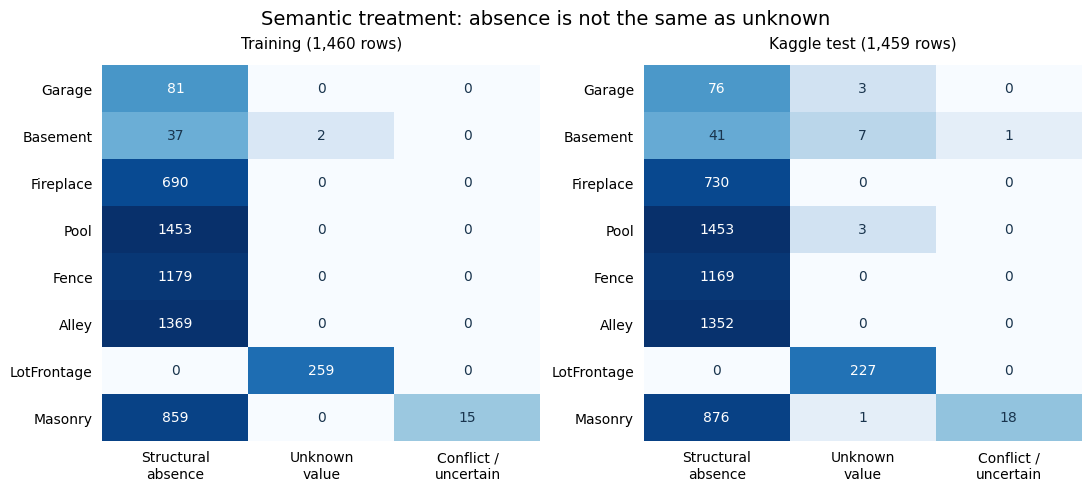

In [9]:
def semantic_group_counts(raw, cleaned):
    absent, unknown, uncertain = {}, {}, {}
    groups = {
        'Garage': ('HasGarage', prep.GARAGE_CATS + ['GarageYrBlt', 'GarageCars', 'GarageArea']),
        'Basement': ('HasBasement', prep.BSMT_CATS + prep.BSMT_NUMERIC),
        'Fireplace': ('HasFireplace', ['FireplaceQu']),
        'Pool': ('HasPool', ['PoolQC']),
        'Masonry': ('HasMasonryVeneer', ['MasVnrType', 'MasVnrArea']),
    }
    conflict_columns = {'Garage': 'GarageConflict', 'Basement': 'BasementConflict',
                        'Fireplace': 'FireplaceConflict', 'Pool': 'PoolConflict', 'Masonry': 'MasonryConflict'}
    for group, (presence, fields) in groups.items():
        absent[group] = cleaned[presence].eq(0) & cleaned[presence + 'Unknown'].eq(0)
        flags = [c + 'Unknown' for c in fields if c + 'Unknown' in cleaned]
        unknown[group] = cleaned[flags].eq(1).any(axis=1)
        conflict = cleaned[conflict_columns[group]].eq(1)
        # A positive pool with missing quality is an unknown description, not contradictory existence.
        if group in ['Pool', 'Fireplace']:
            conflict = conflict & ~unknown[group]
        uncertain[group] = conflict | cleaned[presence + 'Unknown'].eq(1)
    for group, feature, no_feature in [('Fence', 'Fence', 'NoFence'), ('Alley', 'Alley', 'NoAlley')]:
        absent[group] = cleaned[feature].eq(no_feature)
        unknown[group] = cleaned[feature].eq('Unknown')
        uncertain[group] = pd.Series(False, index=raw.index)
    absent['LotFrontage'] = pd.Series(False, index=raw.index)
    unknown['LotFrontage'] = cleaned.LotFrontageUnknown.eq(1)
    uncertain['LotFrontage'] = pd.Series(False, index=raw.index)
    records = []
    for group in ['Garage', 'Basement', 'Fireplace', 'Pool', 'Fence', 'Alley', 'LotFrontage', 'Masonry']:
        conflict_mask = uncertain[group]
        unknown_mask = unknown[group] & ~conflict_mask
        absence_mask = absent[group] & ~conflict_mask & ~unknown_mask
        assert not (absence_mask & unknown_mask).any()
        records.append([group, int(absence_mask.sum()), int(unknown_mask.sum()), int(conflict_mask.sum())])
    return pd.DataFrame(records, columns=['Group', 'Structural absence', 'Unknown value', 'Conflict / uncertain']).set_index('Group')

semantic_counts = {'Training (1,460 rows)': semantic_group_counts(train_raw, clean_train),
                   'Kaggle test (1,459 rows)': semantic_group_counts(test_raw, clean_test)}
max_shade = max(np.log1p(table.to_numpy()).max() for table in semantic_counts.values())
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.8), layout='constrained')
for ax, (label, table) in zip(axes, semantic_counts.items()):
    counts = table.to_numpy()
    ax.imshow(np.log1p(counts), cmap='Blues', vmin=0, vmax=max_shade, aspect='auto')
    ax.set_xticks(range(3), ['Structural\nabsence', 'Unknown\nvalue', 'Conflict /\nuncertain'])
    ax.set_yticks(range(len(table)), table.index)
    ax.tick_params(length=0, pad=7)
    ax.set_title(label, fontsize=11, pad=12)
    for row in range(counts.shape[0]):
        for col in range(3):
            ax.text(col, row, str(counts[row, col]), ha='center', va='center', fontsize=10,
                    color='white' if np.log1p(counts[row, col]) > max_shade * .58 else '#19344d')
    for spine in ax.spines.values():
        spine.set_visible(False)
fig.suptitle('Semantic treatment: absence is not the same as unknown', fontsize=14)
plt.show()
plt.close(fig)

**Interpretation.** Optional-feature absence accounts for many NA tokens, particularly pools, fences and alleys. Frontage gaps are genuinely unknown measurements. Test-only garage/basement gaps and pool-quality exceptions require separate rules. Masonry conflicts and an entirely missing basement block remain explicitly uncertain; a universal fill value would erase these distinctions.

# 10. Feature Engineering
Five presence features are created in semantic cleaning; four aggregates run after numerical imputation in the reusable pipeline. This preview uses observed values and may retain missing results.

| Feature | Formula / interpretation |
|---|---|
| HasGarage, HasBasement, HasFireplace, HasPool, HasMasonryVeneer | Supported existence with separate unknown-status flags. |
| TotalIndoorAreaSF | GrLivArea + TotalBsmtSF; includes unfinished basement, not only finished living area. |
| FinishedBasementSF | BsmtFinSF1 + BsmtFinSF2. |
| BathroomEquivalent | FullBath + BsmtFullBath + 0.5 × (HalfBath + BsmtHalfBath); declared capacity heuristic. |
| TotalPorchSF | OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch; decks excluded. |

No target, neighborhood prices, arbitrary interactions or sale-derived ages enter these definitions. Porch components remain available because different porch types are not equivalent.

In [10]:
engineering_preview = prep.PropertyFeatureEngineer().transform(clean_train)
display(engineering_preview[prep.PRESENCE + prep.ENGINEERED].head(5))
assert np.allclose(engineering_preview.FinishedBasementSF, clean_train.BsmtFinSF1 + clean_train.BsmtFinSF2)
assert np.allclose(engineering_preview.TotalIndoorAreaSF, clean_train.GrLivArea + clean_train.TotalBsmtSF)

,HasGarage,HasBasement,HasFireplace,HasPool,HasMasonryVeneer,TotalIndoorAreaSF,FinishedBasementSF,BathroomEquivalent,TotalPorchSF
0,1.0,1.0,0.0,0.0,1.0,2566.0,706.0,3.5,61.0
1,1.0,1.0,1.0,0.0,0.0,2524.0,978.0,2.5,0.0
2,1.0,1.0,1.0,0.0,1.0,2706.0,486.0,3.5,42.0
3,1.0,1.0,1.0,0.0,0.0,2473.0,216.0,2.0,307.0
4,1.0,1.0,1.0,0.0,1.0,3343.0,655.0,3.5,84.0


# 11. Feature Review / Selection Decisions
Retain property predictors including Utilities, Street, Condition2, RoofMatl and Heating. Member 2's dominance evidence warrants review, but rarity does not establish irrelevance. Keep unknown indicators fixed by schema even when constant in the current training sample: test-only missingness still needs a stable representation.

Exclude Id and the five availability-restricted fields; retain all rows, including unusual large houses. No supervised feature selection is performed.

**Redundancy limitation:** GrLivArea equals its floor components; TotalBsmtSF equals its components; new aggregates create exact dependencies too. Full one-hot blocks also introduce reference-category dependencies for some estimators. The default retains sources and aggregates transparently. Member 4 must account for rank/regularization when attaching an estimator; full column rank is not guaranteed. Later data-dependent selection belongs inside training folds.

In [11]:
n_train = numeric_evidence(train_raw, prep.NUMERIC)
identity_checks = {
    'GrLivArea equals floor components': bool(np.isclose(n_train.GrLivArea, n_train['1stFlrSF'] + n_train['2ndFlrSF'] + n_train.LowQualFinSF).all()),
    'TotalBsmtSF equals basement components': bool(np.isclose(n_train.TotalBsmtSF, n_train[prep.BSMT_PARTS].sum(axis=1)).all()),
    'Id and restricted fields absent': not bool(set(prep.EXCLUDED) & set(clean_train.columns)),
}
display(pd.Series(identity_checks, name='verified').to_frame())

,verified
GrLivArea equals floor components,True
TotalBsmtSF equals basement components,True
Id and restricted fields absent,True


# 12. Categorical Encoding
Nominal columns use training-fitted OneHotEncoder(handle_unknown='ignore'). An unseen category produces an all-zero block rather than an invented category or rank. Known Unknown/absence categories and explicit unknown flags remain distinct where applicable. Test-only MSSubClass=150 demonstrates the need for unseen handling.

True ordinals use explicit dictionary ranks. Unknown values are imputed from applicable training rows and retain Unknown=1; absence remains rank 0 with a presence indicator. Spacing is a representation assumption, not equal economic value. No vocabularies are learned by combining train and Kaggle test.

In [12]:
print('Test building classes absent from training:', sorted(set(clean_test.MSSubClass) - set(clean_train.MSSubClass)))
display(pd.DataFrame({'feature': ['MSSubClass', 'Fence', 'BsmtFinType1', 'BsmtExposure', 'GarageFinish'],
                      'encoding': ['one-hot', 'one-hot', 'one-hot', 'No < Mn < Av < Gd', 'Unf < RFn < Fin']}))

Test building classes absent from training: ['150']


,feature,encoding
0,MSSubClass,one-hot
1,Fence,one-hot
2,BsmtFinType1,one-hot
3,BsmtExposure,No < Mn < Av < Gd
4,GarageFinish,Unf < RFn < Fin


# 13. Numerical Imputation
ApplicableMedianImputer learns statistics only in fit. Garage/basement and amenity-quality medians exclude confirmed inapplicable observations. LotFrontage uses the ordinary training median. Count/ordinal median placeholders may be fractional; these represent uncertainty rather than observed quantities. Missing basement totals are rebuilt from filled components.

If a training fold has no applicable observed values, the component uses a documented fallback (0, or 1900 for a year) and emits a warning. Unknown flags remain set. That fold needs review; warnings are not suppressed. No imputation is fitted on all labelled rows.

# 14. Transformations and Scaling
The factory offers unscaled and scaled configurations with identical semantic cleaning, imputation and feature definitions. StandardScaler applies to numerical and ordinal-score branches; one-hot columns and binary indicators remain unscaled.

log_numeric=False is the default. The optional fixed log1p list contains LotArea, LotFrontage, GrLivArea, MasVnrArea and TotalIndoorAreaSF. Skewed size measurements motivate this candidate; no model scores select it. Logarithms preserve zero and do not delete outliers. SalePrice stays unchanged; target transformation belongs to Member 4.

In [13]:
display(n_train[['LotArea', 'LotFrontage', 'GrLivArea', 'MasVnrArea', 'GarageArea']].skew().round(3).rename('training skew (audit only)').to_frame())
print('Optional fixed log1p columns:', prep.DEFAULT_LOG_COLUMNS)
print('Target unchanged:', y.equals(train_raw.SalePrice))

,training skew (audit only)
LotArea,12.208
LotFrontage,2.164
GrLivArea,1.367
MasVnrArea,2.669
GarageArea,0.180


Optional fixed log1p columns: ['LotArea', 'LotFrontage', 'GrLivArea', 'MasVnrArea', 'TotalIndoorAreaSF']
Target unchanged: True


# 15. Reusable Pipeline Implementation
Runtime order: property allowlist and semantic cleaning → training-fitted imputation → deterministic aggregates → numerical/ordinal and one-hot branches. Engineering is explained earlier for readability but runs after imputation to keep formulas consistent.

Import the public components directly; Member 4 need not copy notebook cells. build_preprocessor returns a fresh unfitted object, and get_feature_names returns exact fitted output ordering.

**Notebook = explanation, evidence and verification. `preprocessing.py` = reusable implementation for Member 4.** EDA mainly records observations and can remain in a notebook. Preprocessing must apply the same rules repeatedly to training folds, validation data and future inputs; an importable module keeps those rules consistent without copying cells.

In [14]:
unfitted_example = build_preprocessor(configuration='scaled', log_numeric=False)
assert not hasattr(unfitted_example.named_steps['impute'], 'statistics_')
display(pd.DataFrame({'step': list(unfitted_example.named_steps),
                      'component': [type(v).__name__ for v in unfitted_example.named_steps.values()]}))
assert clone(unfitted_example).get_params()['semantic__max_year'] == 2100

,step,component
0,semantic,AmesSemanticCleaner
1,impute,ApplicableMedianImputer
2,engineer,PropertyFeatureEngineer
3,encode,ColumnTransformer


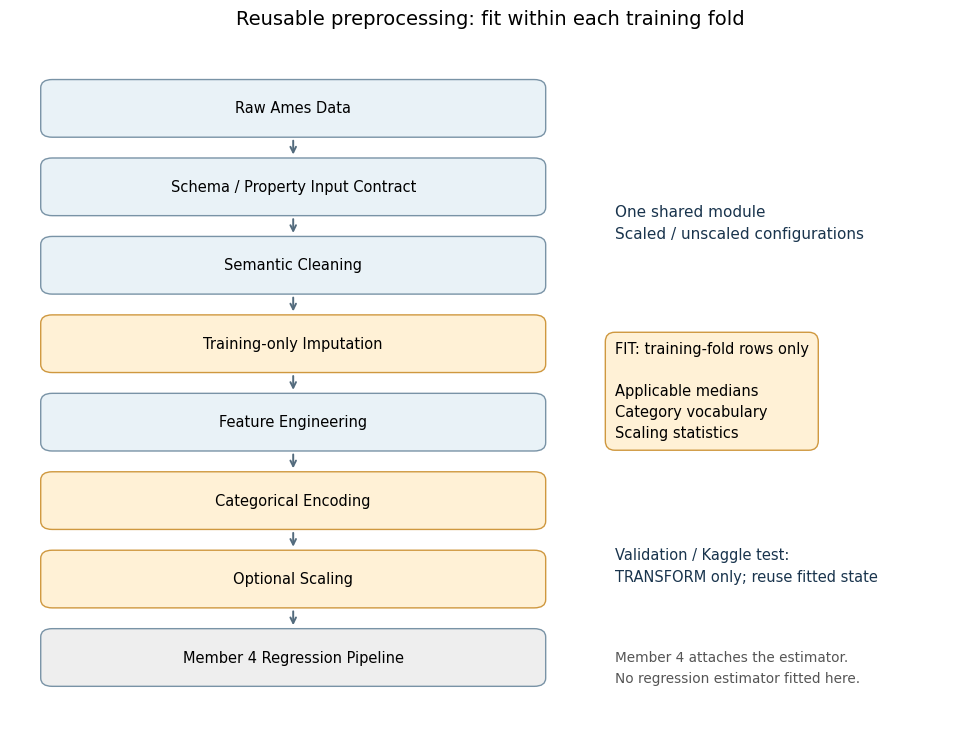

In [15]:
labels = ['Raw Ames Data', 'Schema / Property Input Contract', 'Semantic Cleaning',
          'Training-only Imputation', 'Feature Engineering', 'Categorical Encoding',
          'Optional Scaling', 'Member 4 Regression Pipeline']
fig, ax = plt.subplots(figsize=(10.0, 7.8))
ax.set(xlim=(0, 1), ylim=(0, 1))
ax.axis('off')
ax.set_title('Reusable preprocessing: fit within each training fold', fontsize=14, pad=16)
ys = np.linspace(.91, .11, len(labels))
for i, (label, y_position) in enumerate(zip(labels, ys)):
    learned = i in [3, 5, 6]
    face = '#fff1d6' if learned else '#e9f2f7'
    if i == 7:
        face = '#eeeeee'
    box = FancyBboxPatch((.04, y_position - .034), .51, .068,
                         boxstyle='round,pad=0.008,rounding_size=0.012',
                         facecolor=face, edgecolor='#cf983f' if learned else '#7993a6')
    ax.add_patch(box)
    ax.text(.295, y_position, label, ha='center', va='center', fontsize=10.5)
    if i < len(labels) - 1:
        ax.annotate('', xy=(.295, ys[i + 1] + .043), xytext=(.295, y_position - .043),
                    arrowprops={'arrowstyle': '->', 'color': '#536b7d', 'lw': 1.4})
ax.text(.63, .77, 'One shared module\nScaled / unscaled configurations', fontsize=11,
        color='#19344d', va='top', linespacing=1.6)
ax.text(.63, .57, 'FIT: training-fold rows only\n\nApplicable medians\nCategory vocabulary\nScaling statistics',
        fontsize=10.5, va='top', linespacing=1.5,
        bbox={'boxstyle': 'round,pad=.65', 'facecolor': '#fff1d6', 'edgecolor': '#cf983f'})
ax.text(.63, .27, 'Validation / Kaggle test:\nTRANSFORM only; reuse fitted state',
        fontsize=10.5, color='#19344d', va='top', linespacing=1.6)
ax.text(.63, .12, 'Member 4 attaches the estimator.\nNo regression estimator fitted here.',
        fontsize=9.8, color='#555555', va='top', linespacing=1.6)
fig.subplots_adjust(left=.03, right=.99, top=.92, bottom=.04)
plt.show()
plt.close(fig)

**Visual 2 — Implementation boundary.** Orange stages learn only from the current training fold. Semantic rules and feature formulas are deterministic. The diagram groups stages for explanation: ordinal mapping occurs in semantic cleaning, while one-hot encoding and optional numerical scaling are separate branches of the final ColumnTransformer. Member 4 attaches the regression estimator; it is not executed here.

# 16. Preprocessing-Only Verification
The 80/20 split below exists solely to verify code behaviour. It is **not** the group's modelling/evaluation split. No regression estimator or prediction metric is used. Fitted objects remain in this verification scope; the unfitted factory is the handover.

Checks cover immutability, excluded-field invariance, fold-local statistics, category handling, finite aligned matrices, deterministic transformation, semantic exceptions, formula consistency, sparse/dense outputs and both configurations.

In [16]:
fit_index, check_index = train_test_split(X.index.to_numpy(), test_size=0.2, random_state=RANDOM_STATE)
X_fit, X_check = X.loc[fit_index], X.loc[check_index]
assert set(fit_index).isdisjoint(check_index)
assert train_ids.loc[fit_index].index.equals(X_fit.index)
assert y.loc[fit_index].index.equals(X_fit.index)

def dense(a):
    return a.toarray() if sparse.issparse(a) else np.asarray(a)

verification = []
verified_pipelines = {}
for configuration in ['unscaled', 'scaled']:
    pipeline = build_preprocessor(configuration=configuration)
    z_fit = pipeline.fit_transform(X_fit)
    state_before = copy.deepcopy(pipeline.named_steps['impute'].statistics_)
    scale_before = (pipeline.named_steps['encode'].named_transformers_['numeric'].mean_.copy()
                    if configuration == 'scaled' else None)
    z_check = pipeline.transform(X_check)
    z_kaggle = pipeline.transform(X_kaggle)
    names = get_feature_names(pipeline)
    assert len(names) == len(set(names)) == z_fit.shape[1]
    assert z_check.shape == (len(X_check), len(names)) and z_kaggle.shape == (1459, len(names))
    assert all(np.isfinite(dense(z)).all() for z in [z_fit, z_check, z_kaggle])
    assert np.array_equal(dense(z_check), dense(pipeline.transform(X_check)))
    assert np.allclose(dense(pipeline.transform(X_check.iloc[::-1])), dense(z_check)[::-1])
    assert state_before == pipeline.named_steps['impute'].statistics_
    expected_frontage = prep.AmesSemanticCleaner().transform(X_fit).LotFrontage.median()
    assert state_before['LotFrontage'] == expected_frontage
    if scale_before is not None:
        assert np.array_equal(scale_before, pipeline.named_steps['encode'].named_transformers_['numeric'].mean_)
    full_check = train_raw.loc[check_index].copy()
    for c in prep.EXCLUDED:
        if c in full_check:
            full_check[c] = 'deliberately changed audit-only value'
    assert np.array_equal(dense(pipeline.transform(full_check)), dense(z_check))
    assert not any(any(name.split('__', 1)[-1] == c or name.split('__', 1)[-1].startswith(c + '_')
                       for c in prep.EXCLUDED) for name in names)
    unseen = X_check.head(2).copy()
    unseen['Neighborhood'] = '__UNSEEN_NEIGHBORHOOD__'
    assert np.isfinite(dense(pipeline.transform(unseen))).all()
    verified_pipelines[configuration] = pipeline
    verification.append({'configuration': configuration, 'fit_rows': len(X_fit), 'check_rows': len(X_check),
                         'Kaggle_rows': len(X_kaggle), 'output_features': len(names), 'status': 'PASS'})
display(pd.DataFrame(verification))

,configuration,fit_rows,check_rows,Kaggle_rows,output_features,status
0,unscaled,1168,292,1459,297,PASS
1,scaled,1168,292,1459,297,PASS


In [17]:
def clean_record(raw, record_id):
    return prep.AmesSemanticCleaner().transform(raw.loc[raw.Id.eq(record_id)]).iloc[0]

checks = {}
checks['existing garage measurement unknown before imputation'] = pd.isna(clean_record(test_raw, 2577).GarageArea)
checks['unknown pool quality differs from absence'] = clean_record(test_raw, 2421).HasPool == 1 and clean_record(test_raw, 2421).PoolQCUnknown == 1
checks['fully missing basement uncertain'] = clean_record(test_raw, 2121).HasBasementUnknown == 1
checks['supported absent basement bathrooms zero'] = clean_record(test_raw, 2189).BsmtFullBath == 0 and clean_record(test_raw, 2189).HasBasementUnknown == 0
checks['impossible year not guessed'] = pd.isna(clean_record(test_raw, 2593).GarageYrBlt) and clean_record(test_raw, 2593).InvalidYear == 1
checks['masonry conflict keeps area and unknown material'] = clean_record(train_raw, 625).MasVnrArea == 288 and clean_record(train_raw, 625).MasVnrType == 'Unknown'
checks['known basement missing type remains unknown'] = clean_record(train_raw, 333).BsmtFinType2 == 'Unknown'
absent = clean_train.HasGarage.eq(0) & clean_train.HasGarageUnknown.eq(0)
checks['confirmed absent garage quantities zero'] = clean_train.loc[absent, ['GarageArea', 'GarageCars']].eq(0).all().all()
synthetic = X_fit.head(1).copy()
original = float(synthetic.BsmtFinSF1.iloc[0])
synthetic['BsmtFinSF1'] = np.nan
checks['deterministic reconstruction'] = prep.AmesSemanticCleaner().transform(synthetic).BsmtFinSF1.iloc[0] == original
blank = X_fit.head(1).copy(); blank['Alley'] = np.nan
checks['blank alley stays unknown'] = prep.AmesSemanticCleaner().transform(blank).Alley.iloc[0] == 'Unknown'
checks['raw inputs unchanged'] = train_raw.equals(train_snapshot) and test_raw.equals(test_snapshot)
checks['target original dollars'] = y.equals(train_raw.SalePrice)
for name, passed in checks.items():
    assert passed, name
display(pd.Series(checks, name='PASS').to_frame())

,PASS
existing garage measurement unknown before imputation,True
unknown pool quality differs from absence,True
fully missing basement uncertain,True
supported absent basement bathrooms zero,True
impossible year not guessed,True
masonry conflict keeps area and unknown material,True
known basement missing type remains unknown,True
confirmed absent garage quantities zero,True
deterministic reconstruction,True
blank alley stays unknown,True


In [18]:
p_u, p_s = verified_pipelines['unscaled'], verified_pipelines['scaled']
names_u, names_s = get_feature_names(p_u), get_feature_names(p_s)
assert np.array_equal(names_u, names_s)
indicator_positions = np.flatnonzero(np.char.startswith(names_u.astype(str), 'indicators__'))
assert np.array_equal(dense(p_u.transform(X_check))[:, indicator_positions], dense(p_s.transform(X_check))[:, indicator_positions])
optional = build_preprocessor('scaled', log_numeric=True, sparse_output=False)
optional.fit(X_fit)
optional_matrix = optional.transform(X_kaggle)
assert isinstance(optional_matrix, np.ndarray) and np.isfinite(optional_matrix).all()
assert not hasattr(build_preprocessor().named_steps['impute'], 'statistics_')
print('PASS: binary scale invariance; optional log1p; dense output; fresh unfitted factory.')

PASS: binary scale invariance; optional log1p; dense output; fresh unfitted factory.


In [19]:
# Independent checks of learned state, rather than only checking transform succeeds.
fit_clean = prep.AmesSemanticCleaner().transform(X_fit)
fit_imputed = p_s.named_steps['impute'].transform(fit_clean)
fit_engineered = prep.PropertyFeatureEngineer().transform(fit_imputed)
numeric_columns = p_s.named_steps['encode'].transformers_[0][2]
scaler = p_s.named_steps['encode'].named_transformers_['numeric']
assert np.allclose(scaler.mean_, fit_engineered[numeric_columns].mean().to_numpy())
assert np.allclose(scaler.var_, fit_engineered[numeric_columns].var(ddof=0).to_numpy())
encoder = p_s.named_steps['encode'].named_transformers_['nominal']
for feature, vocabulary in zip(prep.NOMINAL, encoder.categories_):
    assert set(vocabulary) == set(fit_clean[feature])
expected_garage = fit_clean.loc[fit_clean.HasGarage.eq(1), 'GarageArea'].median()
assert p_s.named_steps['impute'].statistics_['GarageArea'] == expected_garage
assert p_s.named_steps['impute'].fit_row_count_ == len(X_fit)
# Held-out numerical changes cannot alter fitted state.
perturbed = X_check.head(3).copy()
perturbed['LotFrontage'] = 1000000
state = copy.deepcopy(p_s.named_steps['impute'].statistics_)
p_s.transform(perturbed)
assert state == p_s.named_steps['impute'].statistics_
# Even if y is supplied through Pipeline.fit, the transformers do not use it.
alternate_y = y.loc[fit_index].iloc[::-1].to_numpy()
target_invariance = clone(p_u).fit(X_fit, alternate_y)
assert np.array_equal(dense(target_invariance.transform(X_check)), dense(p_u.transform(X_check)))
# Exercise an all-missing numerical training column; verify the documented warning.
no_frontage = fit_clean.copy()
no_frontage['LotFrontage'] = np.nan
with warnings.catch_warnings(record=True) as observed_warnings:
    warnings.simplefilter('always')
    fallback = prep.ApplicableMedianImputer().fit(no_frontage)
assert fallback.statistics_['LotFrontage'] == 0
assert any('LotFrontage' in str(w.message) for w in observed_warnings)
print('Expected edge-case warning:', str(observed_warnings[0].message))
display(pd.DataFrame({'feature': ['LotFrontage', 'GarageArea'],
                      'fitted_training_statistic': [p_s.named_steps['impute'].statistics_['LotFrontage'], expected_garage],
                      'fit_rows_only': [len(X_fit), len(X_fit)]}))
print('PASS: exact training scaler statistics/vocabulary; applicable median; held-out-state invariance; y invariance; explicit fallback warning.')

Expected edge-case warning: No applicable observed training values; explicit fallback used for LotFrontage


,feature,fitted_training_statistic,fit_rows_only
0,LotFrontage,70.0,1168
1,GarageArea,486.5,1168


PASS: exact training scaler statistics/vocabulary; applicable median; held-out-state invariance; y invariance; explicit fallback warning.


**Visual 3 — Before/after completeness, with uncertainty retained.**
The same 1,459 Kaggle test rows are shown before learned filling and after transformation by the verification pipeline fitted on 1,168 training rows. The first bar distinguishes supported absent-field tokens from genuine unknown/invalid values identified by semantic rules. Its height is not an error count. After-processing unfilled counts concern the numeric representation only; retained flags show that imputation does not recover the true measurement.

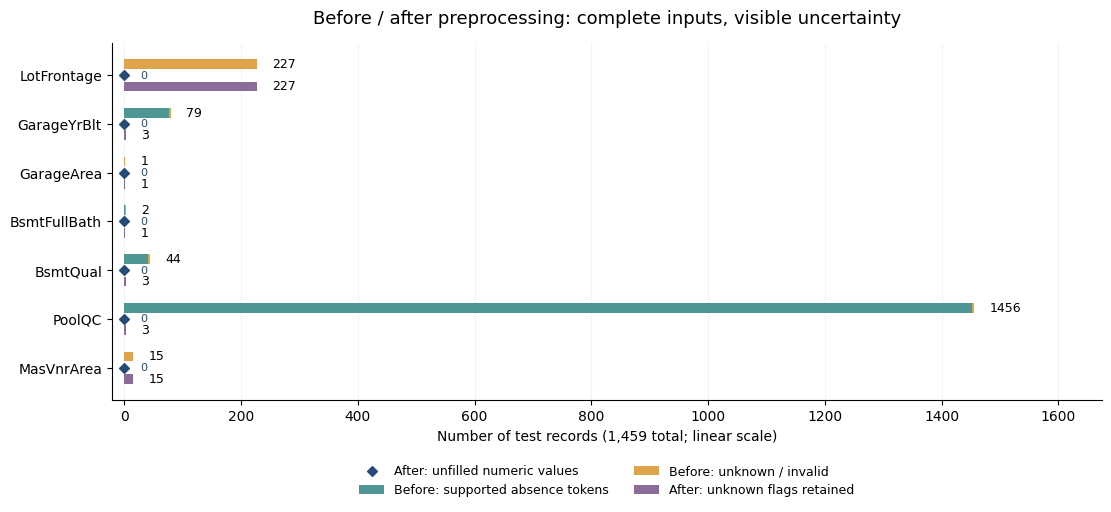

In [20]:
selected = ['LotFrontage', 'GarageYrBlt', 'GarageArea', 'BsmtFullBath', 'BsmtQual', 'PoolQC', 'MasVnrArea']
feature_groups = {'GarageYrBlt': 'HasGarage', 'GarageArea': 'HasGarage',
                  'BsmtFullBath': 'HasBasement', 'BsmtQual': 'HasBasement',
                  'PoolQC': 'HasPool', 'MasVnrArea': 'HasMasonryVeneer'}
prepared_test = dense(p_u.transform(X_kaggle))
output_names = list(get_feature_names(p_u))
comparison_records = []
for feature in selected:
    raw_gap = test_raw[feature].isna() | test_raw[feature].eq('NA')
    group = feature_groups.get(feature)
    absence = (clean_test[group].eq(0) & clean_test[group + 'Unknown'].eq(0)
               if group else pd.Series(False, index=test_raw.index))
    absent_tokens = int((raw_gap & absence).sum())
    unknown_before = int(clean_test[feature + 'Unknown'].sum())
    value_column = output_names.index('numeric__' + feature)
    flag_column = output_names.index('indicators__' + feature + 'Unknown')
    unfilled_after = int((~np.isfinite(prepared_test[:, value_column])).sum())
    flags_after = int(prepared_test[:, flag_column].sum())
    assert unfilled_after == 0 and flags_after == unknown_before
    comparison_records.append([feature, absent_tokens, unknown_before, unfilled_after, flags_after])
comparison = pd.DataFrame(comparison_records, columns=['Feature', 'Absent_tokens', 'Unknown_before', 'Unfilled_after', 'Flags_retained'])
y_positions = np.arange(len(comparison))
fig, ax = plt.subplots(figsize=(11.0, 5.0), layout='constrained')
ax.barh(y_positions - .23, comparison.Absent_tokens, height=.2, color='#4d9693', label='Before: supported absence tokens')
ax.barh(y_positions - .23, comparison.Unknown_before, left=comparison.Absent_tokens,
        height=.2, color='#dda44b', label='Before: unknown / invalid')
ax.scatter(comparison.Unfilled_after, y_positions, marker='D', s=25, color='#254c77', label='After: unfilled numeric values', zorder=3)
ax.barh(y_positions + .23, comparison.Flags_retained, height=.2, color='#8a6b99', label='After: unknown flags retained')
maximum = int((comparison.Absent_tokens + comparison.Unknown_before).max())
for i, row in comparison.iterrows():
    total = row.Absent_tokens + row.Unknown_before
    ax.text(total + maximum * .018, i - .23, str(total), va='center', fontsize=9)
    ax.text(maximum * .018, i, '0', va='center', fontsize=8, color='#254c77')
    ax.text(row.Flags_retained + maximum * .018, i + .23, str(row.Flags_retained), va='center', fontsize=9)
ax.set_yticks(y_positions, comparison.Feature)
ax.invert_yaxis()
ax.set_xlim(-maximum * .015, maximum * 1.15)
ax.set_xlabel('Number of test records (1,459 total; linear scale)')
ax.set_title('Before / after preprocessing: complete inputs, visible uncertainty', fontsize=13, pad=14)
ax.grid(axis='x', alpha=.15)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(.5, -.15), ncol=2, frameon=False, fontsize=9)
plt.show()
plt.close(fig)

**Interpretation.** Confirmed no-pool and no-garage cases are valid absence states, not defective rows. Numerical outputs contain no unresolved values after preprocessing, but original unknown/invalid-value flags remain. The garage-year unknown count includes the invalid recorded year 2207; imputation supplies a representation rather than establishing its true date.

# 17. Processed Output Policy
The notebook regenerates three lightweight local handover artifacts under `data/processed/member_03/`: README.md, preprocessing_manifest.json and feature_summary.csv. The existing `.gitignore` excludes this directory; no ignore rules are changed. No processed matrix or fitted object is exported.

The unfitted factory remains the primary handover. Preprocessing learned from all 1,460 labelled rows before CV would expose validation information through medians, vocabularies and scaling statistics. Member 4 must fit it inside each fold. Full-fit matrices may be generated later for final fitting or a clearly labelled demonstration only after validation strategy and decisions are complete.

Feature counts below describe the temporary correctness split, not a universal feature dimension or a modelling split. Independent folds can learn different one-hot vocabularies. These local artifacts can be recreated by running this notebook; they need not be committed.

In [21]:
PROCESSED_DIR = ROOT / 'data/processed/member_03'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
feature_summary = pd.DataFrame([
    ['Raw training columns', train_raw.shape[1], 'Includes target, Id and audit-only transaction fields.'],
    ['Raw predictor columns excluding Id and target', train_raw.shape[1] - 2, 'Before five prediction-availability exclusions.'],
    ['Default property predictors', len(prep.PROPERTY_COLUMNS), 'Raw input allowlist; no target or transaction fields.'],
    ['Engineered presence flags', len(prep.PRESENCE), 'Target-free presence with separate unknown-status indicators.'],
    ['Engineered area/bath aggregates', len(prep.ENGINEERED), 'Deterministic quantities, derived after imputation.'],
    ['Missingness/consistency indicators', len(prep.INDICATORS), 'Schema-defined flags; some may be constant in a fold.'],
    ['Prepared columns before encoding', fit_engineered.shape[1], 'Includes the 74 source properties and derived features.'],
    ['Encoded features, unscaled verification fit', len(names_u), 'Fit on 1168 temporary verification-training rows only; fold-dependent.'],
    ['Encoded features, scaled verification fit', len(names_s), 'Same semantic definitions and fit rows; fold-dependent.'],
], columns=['Stage', 'Feature_Count', 'Notes'])
manifest = {
    'artifact_type': 'local_preprocessing_handover_metadata',
    'group': '2026-AI-08K',
    'member': {'number': 3, 'name': 'Ahamed M.A.W', 'student_id': 'IT24103352'},
    'target': {'name': 'SalePrice', 'representation': 'original dollars; never used to construct predictors'},
    'raw_shapes': {'train': list(train_raw.shape), 'test': list(test_raw.shape)},
    'excluded_from_feature_matrix': prep.EXCLUDED,
    'prediction_availability_exclusions': [c for c in prep.EXCLUDED if c not in ['Id', 'SalePrice']],
    'property_input_columns': prep.PROPERTY_COLUMNS,
    'engineered_features': prep.PRESENCE + prep.ENGINEERED,
    'missingness_consistency_indicators': prep.INDICATORS,
    'pipeline_configurations': {
        'available': ['unscaled', 'scaled'], 'default': 'unscaled',
        'log_numeric_default': False, 'optional_log_columns': prep.DEFAULT_LOG_COLUMNS,
        'sparse_output_default': True,
        'factory_import': 'from src.member_03 import build_preprocessor',
    },
    'package_versions': versions,
    'raw_file_sha256': fingerprints,
    'implementation_sha256': {name: hashlib.sha256((ROOT / name).read_bytes()).hexdigest()
                              for name in ['src/member_03/preprocessing.py', 'src/member_03/__init__.py']},
    'verification_only': {
        'purpose': 'Preprocessing correctness, NOT the group modelling split',
        'random_state': RANDOM_STATE, 'training_rows': len(X_fit), 'held_out_rows': len(X_check),
        'training_ids': train_ids.loc[fit_index].astype(int).tolist(),
        'held_out_ids': train_ids.loc[check_index].astype(int).tolist(),
        'encoded_feature_counts': {'unscaled': len(names_u), 'scaled': len(names_s)},
    },
    'primary_handover': 'UNFITTED build_preprocessor() factory; fit inside each training/CV fold',
    'generated_matrices': False, 'fitted_objects_exported': False, 'regression_model_trained': False,
    'regeneration': 'Run notebooks/Member_03/Member3_Preprocessing_FeatureEngineering.ipynb from start to finish.',
    'limitations': ['Uncertain basement presence remains flagged', 'Ordinal spacing is representational',
                    'Neutral year placeholders are not observed dates', 'Exact feature dependencies remain',
                    'Excluded sale chronology and MiscVal conflicts remain audit-only'],
}
readme = """# Member 3 local preprocessing handover

Group 2026-AI-08K | Ahamed M.A.W | IT24103352

These files are generated metadata, not a processed training dataset. They are
ignored by the existing data/processed rule and regenerated by the Member 3 notebook.

## Primary handover

Import the reusable, UNFITTED factory from the repository root:

```python
from src.member_03 import build_preprocessor
preprocessor = build_preprocessor(configuration='unscaled')
# Alternative: configuration='scaled'; log_numeric=False by default.
```

Member 4 attaches this object inside the regression pipeline and fits it only
on each training/CV fold. Validation and Kaggle test rows use transform only.
A single fully preprocessed training CSV is NOT the primary handover: learning
imputation, category vocabularies or scaling from all 1,460 labelled rows before
CV would leak validation information. Independent folds may have different
encoded feature counts.

Full-fit matrices may be produced later for final fitting or a clearly labelled
demonstration only after the validation strategy and decisions are complete.
Do not use such matrices for later cross-validation. No matrix, fitted object,
regression estimator or model score is created by this handover step.

## Contents

- preprocessing_manifest.json: raw fingerprints, versions, input exclusions,
  feature definitions and temporary verification-split provenance.
- feature_summary.csv: compact stage counts; encoded counts refer only to the
  1,168-row correctness fit, not the group's modelling split.
- README.md: this usage and leakage policy.

Run notebooks/Member_03/Member3_Preprocessing_FeatureEngineering.ipynb to
regenerate all three files. The notebook is the explanatory assignment evidence;
src/member_03/preprocessing.py is the reusable implementation.
"""
(PROCESSED_DIR / 'README.md').write_text(readme, encoding='utf-8')
(PROCESSED_DIR / 'preprocessing_manifest.json').write_text(json.dumps(manifest, indent=2) + '\n', encoding='utf-8')
feature_summary.to_csv(PROCESSED_DIR / 'feature_summary.csv', index=False)
# Read-back checks prove that the local handover files match this run.
loaded_manifest = json.loads((PROCESSED_DIR / 'preprocessing_manifest.json').read_text(encoding='utf-8'))
assert loaded_manifest['verification_only']['encoded_feature_counts']['unscaled'] == len(names_u)
assert loaded_manifest['raw_file_sha256'] == fingerprints
pd.testing.assert_frame_equal(pd.read_csv(PROCESSED_DIR / 'feature_summary.csv'), feature_summary)
assert set(loaded_manifest['verification_only']['training_ids']).isdisjoint(loaded_manifest['verification_only']['held_out_ids'])
assert all(hashlib.sha256((RAW_DIR / name).read_bytes()).hexdigest() == value for name, value in fingerprints.items())
display(feature_summary)
print('Generated README.md, preprocessing_manifest.json and feature_summary.csv; no matrices or fitted objects exported.')

,Stage,Feature_Count,Notes
0,Raw training columns,81,"Includes target, Id and audit-only transaction..."
1,Raw predictor columns excluding Id and target,79,Before five prediction-availability exclusions.
2,Default property predictors,74,Raw input allowlist; no target or transaction ...
3,Engineered presence flags,5,Target-free presence with separate unknown-sta...
4,Engineered area/bath aggregates,4,"Deterministic quantities, derived after imputa..."
5,Missingness/consistency indicators,52,Schema-defined flags; some may be constant in ...
6,Prepared columns before encoding,135,Includes the 74 source properties and derived ...
7,"Encoded features, unscaled verification fit",297,Fit on 1168 temporary verification-training ro...
8,"Encoded features, scaled verification fit",297,Same semantic definitions and fit rows; fold-d...


Generated README.md, preprocessing_manifest.json and feature_summary.csv; no matrices or fitted objects exported.


# 18. Decision Log
The log records issue, evidence, treatment, alternatives, justification and leakage implications. It is human-readable decision evidence, not a set of unsupported performance claims.

In [22]:
decision_log = pd.read_csv(REPORT_DIR / 'preprocessing_feature_decision_log.csv', keep_default_na=False)
assert decision_log.Decision_ID.is_unique and decision_log.ne('').all().all()
display(decision_log[['Decision_ID', 'Area', 'Feature_or_Group', 'Decision']])

,Decision_ID,Area,Feature_or_Group,Decision
0,M3-01,Parsing,All raw columns; MasVnrType,Preserve None and NA; only blank cells missing...
1,M3-02,Input contract,Id; SalePrice,Separate IDs and original-dollar y; explicit p...
2,M3-03,Input contract,SaleType; SaleCondition; YrSold; MoSold; MiscVal,Exclude from prediction and cleaning logic; re...
3,M3-04,Missingness,Garage fields,NoGarage and zero area/cars only on supported ...
4,M3-05,Missingness,GarageYrBlt,Bounds 1800..2100; invalid unknown; absent gar...
5,M3-06,Missingness,Basement categories,NoBasement only with zero total and no positiv...
6,M3-07,Missingness,Basement quantities,2121 unknown status and applicable medians; 21...
7,M3-08,Reconstruction,Basement area components/total,Recover total if all parts known; one missing ...
8,M3-09,Missingness,FireplaceQu; PoolQC,Presence flags; absence rank 0; unknown qualit...
9,M3-10,Missingness,Alley; Fence; MiscFeature,Explicit absence for literal NA; blank Unknown...


# 19. Feature Schema
The complete schema records meaning, raw dtype, semantic type, absence treatment, imputation, encoding, scaling and availability, including every derived indicator. One-hot names depend only on the fitted training fold and are available through get_feature_names.

Dictionary names/spellings differ from some CSV labels (Bedroom/BedroomAbvGr, Kitchen/KitchenAbvGr and category spellings). Use actual CSV columns; nominal levels are not silently rewritten using approximate spelling.

In [23]:
display(feature_schema.loc[feature_schema.Feature.isin(['Id', 'SalePrice', 'MSSubClass', 'LotFrontage', 'GarageYrBlt', 'MasVnrType', 'TotalIndoorAreaSF', 'HasBasementUnknown']),
                           ['Feature', 'Semantic_Type', 'Missing_Value_Strategy', 'Encoding', 'Default_Use']])
assert set(clean_train.columns).issubset(set(feature_schema.Feature))
assert set(prep.ENGINEERED).issubset(set(feature_schema.Feature))
print(f'Schema coverage: {len(train_raw.columns)} original columns; {len(feature_schema)} original/derived entries.')

,Feature,Semantic_Type,Missing_Value_Strategy,Encoding,Default_Use
0,Id,identifier,must be unique and present,excluded,exclude
1,MSSubClass,nominal categorical,explicit Unknown category,canonical category string then one-hot,include
3,LotFrontage,numerical measurement,training-fold median; applicability-aware wher...,numeric,include
25,MasVnrType,nominal categorical,explicit Unknown category,one-hot; unseen category -> all-zero block,include
59,GarageYrBlt,year/date-related,training-fold median; applicability-aware wher...,numeric,include
80,SalePrice,target,must be present and finite,separate original-dollar y,exclude
86,TotalIndoorAreaSF,numerical measurement,Flags before imputation; aggregates after impu...,numeric,include
130,HasBasementUnknown,binary,Flags before imputation; aggregates after impu...,numeric,include


Schema coverage: 81 original columns; 142 original/derived entries.


# 20. Member 4 Handover
**Member 3 completed:** explicit raw-token loading; property-only contract; semantic absence/unknown handling; documented imputation and ordinal orders; nine interpretable presence/aggregate features; targeted outlier/feature review; scaled/unscaled reusable preprocessing; executable correctness checks; decision log, schema, three preprocessing visuals and regenerable local handover metadata.

From the repository root (or after adding its resolved path to Python's import path):
```python
from src.member_03 import load_ames_data, build_preprocessor, get_feature_names
train, test = load_ames_data(repository_root)
y = train['SalePrice'].copy()  # original dollars
X = train.drop(columns=['Id', 'SalePrice'])
preprocessor = build_preprocessor(configuration='unscaled')
# Alternative: configuration='scaled', log_numeric=False
# Attach this UNFITTED object inside Member 4's estimator pipeline.
```

**Remaining for Member 4:** choose validation, attach regression estimators, fit preprocessing within each training/CV fold, evaluate and compare predictions, address estimator-specific rank/representation needs, decide target transformation, interpret results and make recommendations. None of those modelling activities occurs here.

Never fit preprocessing on all labelled rows before CV or learn statistics from Kaggle test. The temporary correctness split is not a modelling recommendation. SalePrice is unchanged; optional log1p target handling and inverse transformation belong to Member 4.

**Limitations:** fully missing basement status remains uncertain; ordinal spacing is an assumption; neutral year placeholders are not observed dates; exact feature dependencies remain documented; actual sale chronology and the MiscVal contradiction are audit-only; broad plausible bounds do not prove every date correct. Earlier EDA examined all labelled rows, so a later holdout is not wholly untouched by exploration.

**AI-use transparency:** this implementation and explanatory draft were prepared with AI coding assistance using the assignment, raw dictionary and upstream evidence. The author should review the decisions and declare that assistance in the final submission. Execution checks validate preprocessing only; no model performance claims were made.

Local usage policy: [processed handover README](../../data/processed/member_03/README.md). This gitignored file is generated by Section 17; the unfitted Python factory remains the primary integration point.